# Bayesian neural network with mean-field Gaussian variational inference 

This code is an adaptation from Hands-on Bayesian Neural Networks – A Tutorial
for Deep Learning Users. Authors: Laurent Valentin Jospin, Farid Boussaid, Mohammed Bennamoun

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from torch.nn.parameter import Parameter
from torch.distributions.normal import Normal

from torch.utils.data import DataLoader
from torch.optim import Adam

import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [3]:
# -------------
#   LOAD DATA
# -------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    "./data/",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    "./data/",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 60000
Test samples: 10000


In [4]:
# ------------------------------------------------
# A mixin class to attach loss functions to layer
# ------------------------------------------------

class VIModule(nn.Module):
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._internalLosses = []
        self.lossScaleFactor = 1.0
    
    def addLoss(self, func):
        self._internalLosses.append(func)
    
    def evalLosses(self):
        total_loss = 0.0
        for loss_function in self._internalLosses:
            total_loss = total_loss + loss_function(self)
        return total_loss
    
    def evalAllLosses(self):
        total_loss = self.evalLosses() * self.lossScaleFactor
        for module in self.children():
            if isinstance(module, VIModule):
                total_loss = (
                    total_loss
                    + module.evalAllLosses() * self.lossScaleFactor
                )
        return total_loss

In [5]:
# --------------------------------------------------------------------------------------------
# A feed forward layer with a Gaussian prior distribution and a Gaussian variational posterior
# --------------------------------------------------------------------------------------------

class MeanFieldGaussianFeedForward(VIModule):
    
    def __init__(
        self,
        in_features,
        out_features,
        bias=True,
        weightPriorSigma=1.0,
        biasPriorSigma=1.0,
        initPriorSigmaScale=0.01
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.has_bias = bias
        
        # WEIGHT MEAN
        self.weights_mean = nn.Parameter(
            (torch.rand(out_features, in_features) - 0.5)
        )
        
        # WEIGHT LOG STANDARD DEVIATION
        self.lweights_sigma = nn.Parameter(
            torch.log(
                initPriorSigmaScale
                * weightPriorSigma
                * torch.ones(out_features, in_features)
            )
        )
        self.noiseSourceWeights = torch.distributions.Normal(
            torch.zeros(out_features, in_features),
            torch.ones(out_features, in_features)
        )
    
        # KL / VARIATIONAL LOSS TERMS
        self.addLoss(
            lambda s:
            0.5
            * s.getSampledWeights().pow(2).sum()
            / weightPriorSigma**2
        )
        self.addLoss(
            lambda s:
            -self.out_features / 2 * np.log(2 * np.pi)
            - 0.5 * s.samples["wNoiseState"].pow(2).sum()
            - s.lweights_sigma.sum()
        )
        
        # BIAS
        if self.has_bias:
            self.bias_mean = nn.Parameter(
                torch.rand(out_features) - 0.5
            )
            self.lbias_sigma = nn.Parameter(
                torch.log(
                    initPriorSigmaScale
                    * biasPriorSigma
                    * torch.ones(out_features)
                )
            )
            self.noiseSourceBias = torch.distributions.Normal(
                torch.zeros(out_features),
                torch.ones(out_features)
            )
            self.addLoss(
                lambda s:
                0.5
                * s.getSampledBias().pow(2).sum()
                / biasPriorSigma**2
            )
            self.addLoss(
                lambda s:
                -self.out_features / 2 * np.log(2 * np.pi)
                - 0.5 * s.samples["bNoiseState"].pow(2).sum()
                - s.lbias_sigma.sum()
            )
        self.samples = {
            "weights": None,
            "bias": None,
            "wNoiseState": None,
            "bNoiseState": None
        }
    
    def sampleTransform(self, stochastic=True):
        self.samples["wNoiseState"] = (
            self.noiseSourceWeights
            .sample()
            .to(self.weights_mean.device)
        )
        self.samples["weights"] = (
            self.weights_mean
            + torch.exp(self.lweights_sigma)
            * self.samples["wNoiseState"]
            if stochastic
            else self.weights_mean
        )
        
        if self.has_bias:
            self.samples["bNoiseState"] = (
                self.noiseSourceBias
                .sample()
                .to(self.bias_mean.device)
            )
            self.samples["bias"] = (
                self.bias_mean
                + torch.exp(self.lbias_sigma)
                * self.samples["bNoiseState"]
                if stochastic
                else self.bias_mean
            )
    
    def getSampledWeights(self):
        return self.samples["weights"]
    
    def getSampledBias(self):
        return self.samples["bias"]
    
    def forward(self, x, stochastic=True):
        self.sampleTransform(stochastic)
        return nn.functional.linear(
            x,
            self.samples["weights"],
            self.samples["bias"] if self.has_bias else None
        )

In [6]:
# ------------------------------------
# Bayesian Neural Network Architecture
# ------------------------------------

class BayesianMnistNet(VIModule):
    
    def __init__(
        self,
        weightPriorSigma=1.0,
        biasPriorSigma=5.0
    ):
        
        super().__init__()
        
        self.linear1 = MeanFieldGaussianFeedForward(
            in_features=784,
            out_features=64,
            weightPriorSigma=weightPriorSigma,
            biasPriorSigma=biasPriorSigma,
            initPriorSigmaScale=1e-7
        )
        
        self.linear2 = MeanFieldGaussianFeedForward(
            in_features=64,
            out_features=10,
            weightPriorSigma=weightPriorSigma,
            biasPriorSigma=biasPriorSigma,
            initPriorSigmaScale=1e-7
        )
    
    def forward(self, x, stochastic=True):
        
        # Flatten 28x28 image
        x = x.view(x.size(0), -1)
        
        # Bayesian hidden layer
        x = self.linear1(
            x,
            stochastic=stochastic
        )
        x = nn.functional.relu(x)
        
        # Bayesian output layer
        x = self.linear2(
            x,
            stochastic=stochastic
        )
        return nn.functional.log_softmax(x, dim=1)

In [7]:
# --------------------
# Model Initialisation

# --------------------

model = BayesianMnistNet(
    weightPriorSigma=1.0,
    biasPriorSigma=5.0
).to(device)

optimizer = Adam(
    model.parameters(),
    lr=5e-3
)

criterion = nn.NLLLoss(reduction="mean")

print(model)

BayesianMnistNet(
  (linear1): MeanFieldGaussianFeedForward()
  (linear2): MeanFieldGaussianFeedForward()
)


In [8]:
# --------
# Training
# --------

num_epochs = 20

#Store metrics
train_nll_history = []
val_nll_history = []
train_kl_history = []
train_accuracy_history = []
val_accuracy_history = []

# Training
for epoch in range(num_epochs):
    model.train()
    total_train_nll = 0.0
    total_train_kl = 0.0
    total_train_correct = 0
    total_train_samples = 0
    
    # Batches
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        
        # Bayesian forward pass
        pred = model(
            images,
            stochastic=True
        )
        
        # Negative log likelihood
        nll = criterion(
            pred,
            labels
        )
        
        # KL divergence / variational loss
        kl = model.evalAllLosses()
        
        # Scale KL by dataset size
        batch_size = labels.size(0)
        total_loss = (
            len(train_dataset) * nll
            + kl
        )
        
        # Backpropagation
        total_loss.backward()
        optimizer.step()
        
        # Metrics
        total_train_nll += nll.item() * batch_size
        total_train_kl += kl.item()
        
        predictions = torch.argmax(
            pred,
            dim=1
        )
        
        total_train_correct += (
            predictions == labels
        ).sum().item()
        
        total_train_samples += batch_size
    
    # Average Training metrics
    avg_train_nll = (
        total_train_nll
        / total_train_samples
    )
    avg_train_kl = (
        total_train_kl
        / len(train_loader)
    )
    train_accuracy = (
        total_train_correct
        / total_train_samples
    )
    
    # Validation
    model.eval()
    total_val_nll = 0.0
    total_val_correct = 0
    total_val_samples = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            # Deterministic prediction
            pred = model(
                images,
                stochastic=False
            )
            nll = criterion(
                pred,
                labels
            )
            batch_size = labels.size(0)
            total_val_nll += (
                nll.item() * batch_size
            )
            predictions = torch.argmax(
                pred,
                dim=1
            )
            total_val_correct += (
                predictions == labels
            ).sum().item()
            total_val_samples += batch_size
    
    # Average Validation metrics
    avg_val_nll = (
        total_val_nll
        / total_val_samples
    )
    val_accuracy = (
        total_val_correct
        / total_val_samples
    )
    
    # Store Metrics
    train_nll_history.append(avg_train_nll)
    val_nll_history.append(avg_val_nll)
    train_kl_history.append(avg_train_kl)
    train_accuracy_history.append(train_accuracy)
    val_accuracy_history.append(val_accuracy)
    
    if epoch == num_epochs - 1:
        print("=" * 50)
        print(f"Final Epoch: {epoch + 1}/{num_epochs}")
        print("=" * 50)
        print(f"Training NLL:       {avg_train_nll:.4f}")
        print(f"Validation NLL:     {avg_val_nll:.4f}")
        print(f"Training Accuracy:  {train_accuracy:.4f}")
        print(f"Validation Accuracy:{val_accuracy:.4f}")
        print(f"Average KL:         {avg_train_kl:.2f}")

Final Epoch: 20/20
Training NLL:       0.1930
Validation NLL:     0.1609
Training Accuracy:  0.9473
Validation Accuracy:0.9593
Average KL:         13719.05


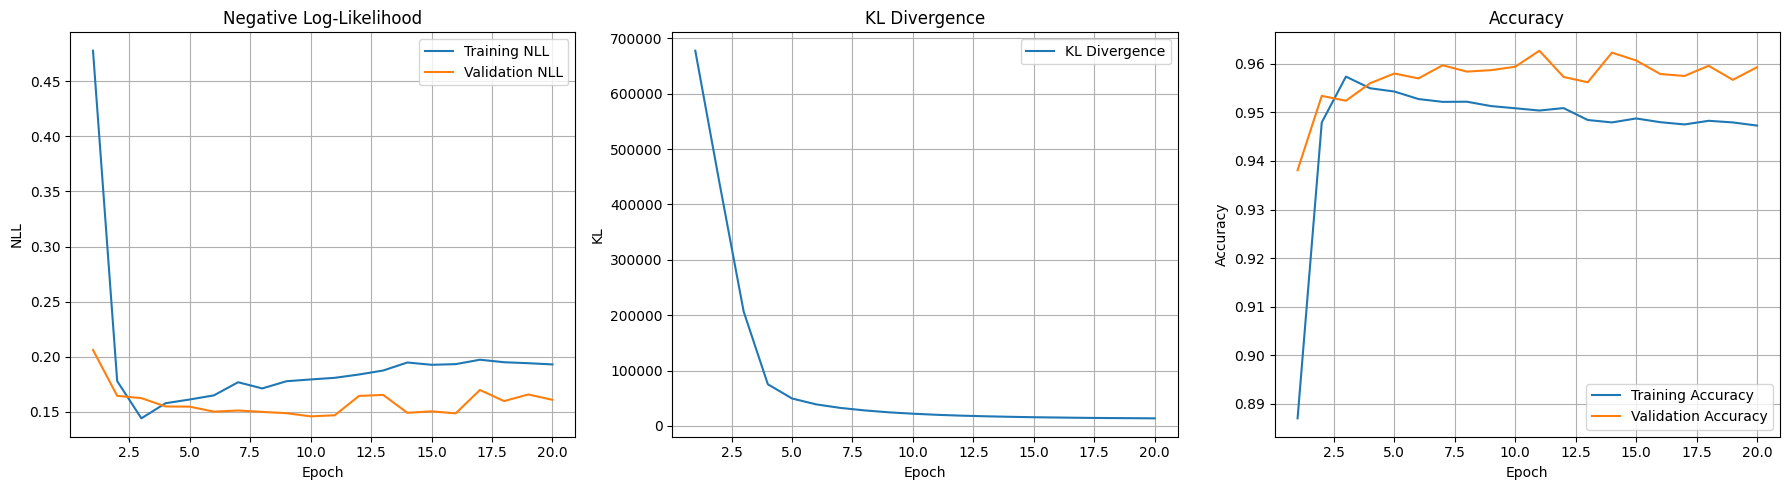

In [9]:
# ------------
# Plot Metrics
# ------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)
epochs = np.arange(1, num_epochs + 1)

axes[0].plot(
    epochs,
    train_nll_history,
    label="Training NLL"
)
axes[0].plot(
    epochs,
    val_nll_history,
    label="Validation NLL"
)
axes[0].set_title("Negative Log-Likelihood")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("NLL")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    epochs,
    train_kl_history,
    label="KL Divergence"
)
axes[1].set_title("KL Divergence")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("KL")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(
    epochs,
    train_accuracy_history,
    label="Training Accuracy"
)
axes[2].plot(
    epochs,
    val_accuracy_history,
    label="Validation Accuracy"
)
axes[2].set_title("Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [10]:
# ----------
# Test Data 
# ----------

model.eval()

total_test_correct = 0
total_test_samples = 0
total_test_nll = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        pred = model(
            images,
            stochastic=False
        )
        
        nll = criterion(
            pred,
            labels
        )
        
        batch_size = labels.size(0)
        total_test_nll += (
            nll.item() * batch_size
        )
        
        predictions = torch.argmax(
            pred,
            dim=1
        )
        
        total_test_correct += (
            predictions == labels
        ).sum().item()
        
        total_test_samples += batch_size
        
test_nll = (
    total_test_nll
    / total_test_samples
)

test_accuracy = (
    total_test_correct
    / total_test_samples
)

print(f"Test NLL:      {test_nll:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test NLL:      0.1609
Test Accuracy: 0.9593


In [22]:
# -----------
# Prediction
# -----------

def test_prediction(index, model, test_loader, device, rotation=0, n_samples=100):

    model.eval()

    images, labels = next(iter(test_loader))

    image = images[index:index+1].to(device)
    label = labels[index].item()

    # Rotate the image
    k = rotation // 90

    if rotation != 0:
        image = torch.rot90(
            image,
            k=k,
            dims=(2, 3)
        ).contiguous()

    # Monte Carlo Sampling
    samples = []

    with torch.no_grad():
        for _ in range(n_samples):

            prediction = model(
                image,
                stochastic=True
            )

            probabilities = torch.exp(prediction)
            samples.append(probabilities)

    samples = torch.stack(samples)
    samples = samples.squeeze(1)

    # Mean Prediction
    mean_probabilities = samples.mean(dim=0)

    predicted_class = torch.argmax(
        mean_probabilities
    ).item()

    # Uncertainty
    std_probabilities = samples.std(dim=0)

    prediction_std = std_probabilities[
        predicted_class
    ].item()

    # Print results
    print("Predicted:", predicted_class)
    print("Actual:   ", label)

    print("\nMean class probabilities:")
    print(mean_probabilities.cpu().numpy())

    print("\nClass probability standard deviations:")
    print(std_probabilities.cpu().numpy())

    print(
        f"\nUncertainty (std) for predicted class: "
        f"{prediction_std:.4f}"
    )

    # Display image
    plt.figure(figsize=(4, 4))

    plt.imshow(
        image[0].squeeze().cpu(),
        cmap="gray"
    )

    plt.title(
        f"Rotation: {rotation}° | "
        f"Predicted: {predicted_class} | "
        f"Actual: {label}\n"
        f"Uncertainty: {prediction_std:.4f}"
    )

    plt.axis("off")

    plt.savefig(
        f"bnn_prediction_index{index}_rotation{rotation}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

Predicted: 7
Actual:    7

Mean class probabilities:
[1.4738910e-12 2.3230893e-09 5.1253915e-07 1.3264045e-06 1.2200866e-12
 1.0836576e-05 6.5692725e-17 9.9998689e-01 1.2602948e-09 4.8724650e-07]

Class probability standard deviations:
[1.3671312e-11 6.6582966e-09 2.3344041e-06 9.1622705e-06 1.0078901e-11
 4.8755912e-05 3.5476628e-16 5.0030289e-05 6.9213377e-09 2.6204818e-06]

Uncertainty (std) for predicted class: 0.0001


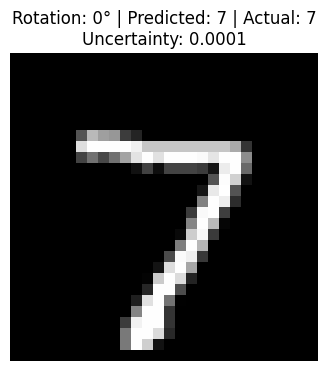

In [23]:
test_prediction(0, model, test_loader, device, rotation=0)

Predicted: 7
Actual:    7

Mean class probabilities:
[3.1343704e-01 2.0975953e-03 7.0678473e-02 5.2877637e-03 1.7555273e-04
 2.3171547e-01 8.2067074e-03 3.3016127e-01 2.9468197e-02 8.7719299e-03]

Class probability standard deviations:
[0.3615662  0.0110342  0.19919847 0.01415112 0.00129026 0.3119939
 0.05885857 0.33768234 0.06671268 0.02791265]

Uncertainty (std) for predicted class: 0.3377


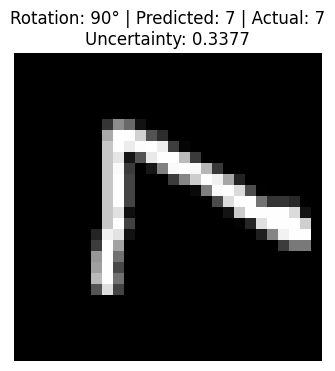

In [24]:
test_prediction(0, model, test_loader, device, rotation=90)

Predicted: 6
Actual:    7

Mean class probabilities:
[3.7863691e-04 4.3890600e-06 1.8852569e-01 1.2359840e-05 4.6252064e-02
 1.3327736e-01 6.3089216e-01 2.3479185e-08 2.9119714e-05 6.2821858e-04]

Class probability standard deviations:
[2.1294248e-03 3.1876232e-05 3.3512715e-01 5.5508179e-05 1.2939939e-01
 2.4446391e-01 4.0490812e-01 8.5924526e-08 6.2442617e-05 3.0402488e-03]

Uncertainty (std) for predicted class: 0.4049


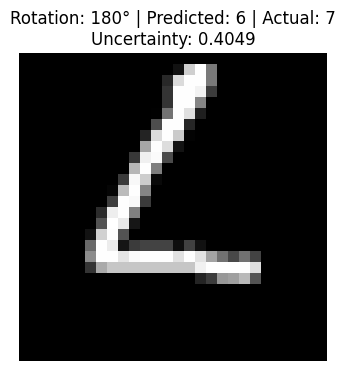

In [25]:
test_prediction(0, model, test_loader, device, rotation=180)

Predicted: 4
Actual:    7

Mean class probabilities:
[5.5139663e-04 2.0304992e-06 1.5914673e-03 2.6134128e-05 9.9624056e-01
 7.2574541e-05 1.1762689e-03 1.9888314e-04 5.1543815e-05 8.9131572e-05]

Class probability standard deviations:
[5.4516899e-03 1.2058855e-05 1.5404347e-02 1.5888928e-04 3.0821651e-02
 4.9647829e-04 8.8278903e-03 1.9314470e-03 3.4406775e-04 4.0674198e-04]

Uncertainty (std) for predicted class: 0.0308


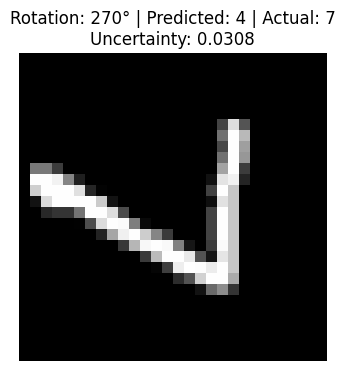

In [26]:
test_prediction(0, model, test_loader, device, rotation=270)